In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Data Generation

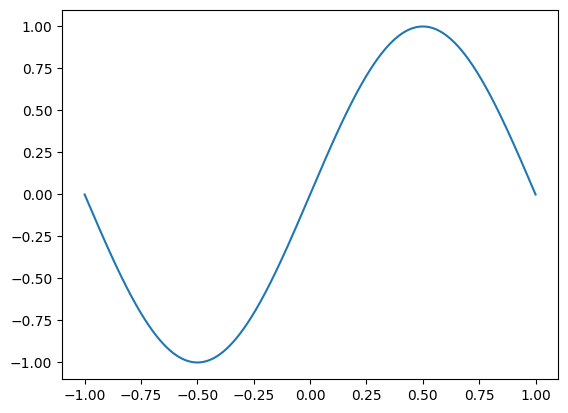

In [10]:
N = 1000 

x = np.linspace(-1,1,N)
y = np.sin(np.pi * x)

plt.plot(x,y)
plt.show()

# regression model fitting using Normal Equation

In [ ]:
# append a column of 1s at the beginning of x for beta_0
x = x.reshape(-1,1)
x = np.c_[np.ones(N), x]
print(x.shape)
print(x[:4])


(1000, 2)
[[ 1.         -1.        ]
 [ 1.         -0.997998  ]
 [ 1.         -0.995996  ]
 [ 1.         -0.99399399]]


In [12]:
X = x
Y = y.reshape(-1,1)

In [13]:
theta = np.linalg.inv(X.T @ X) @ (X.T @ Y)
print(np.round_(theta))

[[-0.]
 [ 1.]]


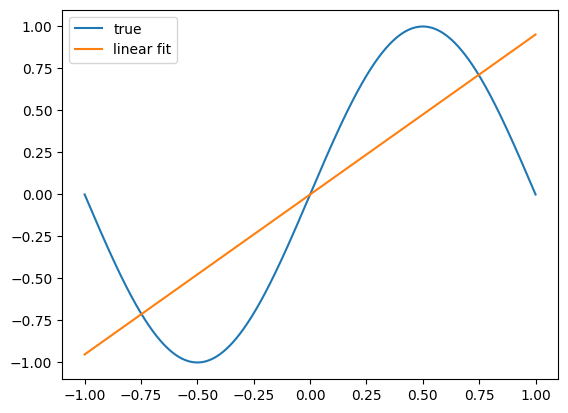

In [14]:
y_hat = X @ theta
plt.plot(x[:,1], y, label = "true")
plt.plot(x[:,1], y_hat, label = "linear fit")
plt.legend()
plt.show()

# Genearlization and testing with higher degree polylomials

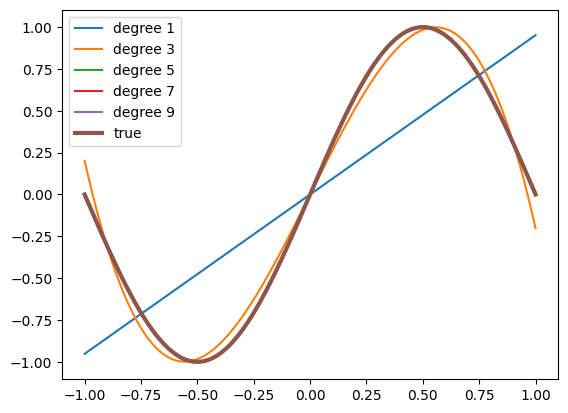

In [24]:
# creatign desgn matrix, X of a given degree d

def design_matrix(x, d):
    x = x.reshape(-1,1)
    x = np.hstack([x**k for k in range(d + 1)]) # k = 0 would add first column of 1s
    return x

for d in [1,3,5,7,9]:
    X = design_matrix(x[:,1],d)
    theta = np.linalg.inv(X.T @ X) @ (X.T @ Y)
    
    y_hat = X @ theta
    
    plt.plot(x[:,1], y_hat, label=f"degree {d}")
    
plt.plot(x[:,1], y, label="true", linewidth=3)
plt.legend()
plt.show()

# measuring the errors 

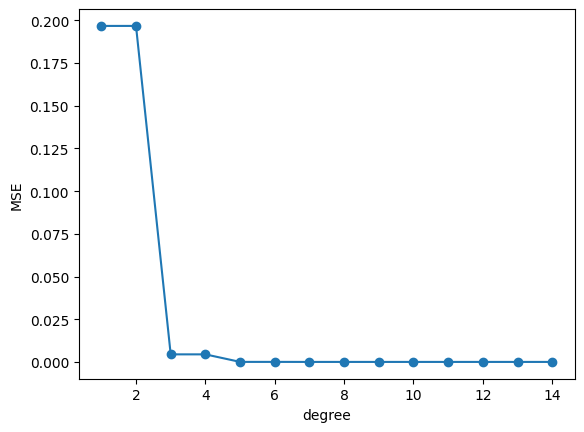

In [25]:
def mse(y, y_hat):
    return np.mean((y-y_hat)**2)

errors = []

for d in range(1, 15):
    X = design_matrix(x[:,1], d)
    theta = np.linalg.inv(X.T @ X) @ X.T @ Y
    y_hat = X @ theta
    errors.append(mse(y, y_hat.flatten()))

plt.plot(range(1,15), errors, marker='o')
plt.xlabel("degree")
plt.ylabel("MSE")
plt.show()
